# Time Series Analysis - Time Series Properties

This notebook covers the **exploratory analysis of time series data** using weather observations.  
The goal is to characterise the key statistical properties of a time series *before* building any forecasting model.

**Topics covered:**
1. Data loading and resampling
2. Visual exploration
3. Decomposition (trend, seasonality, residual)
4. Stationarity testing (ADF & KPSS)
5. Autocorrelation analysis (ACF / PACF)
6. Distribution and residual diagnostics

**Libraries used:** `pandas`, `statsmodels`, `darts`, `matplotlib`, `seaborn`

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

## Dataset

Daily observations from **DWD weather station 02932 (Leipzig)** covering 1975–2024 (50 years, ~18 000 records).  
Variables include temperature, precipitation, humidity, wind, pressure, sunshine, and cloud cover.

**Note on missing values:**  
Several columns have gaps (e.g. `wind_gust_max`, `sunshine_duration`). This is typical for long real-world time series due to sensor failures or data gaps.  
Many TS analysis methods require a complete, evenly-spaced series. So, missing value handling must come before these steps.

In [75]:
df_full = pd.read_csv("data/dwd_02932_climate.csv", sep=";", parse_dates=["date"], index_col="date")
df_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18263 entries, 1975-01-01 to 2024-12-31
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   wind_gust_max              18006 non-null  float64
 1   wind_speed                 18240 non-null  float64
 2   precipitation_height       18263 non-null  float64
 3   precipitation_form         18263 non-null  float64
 4   sunshine_duration          18082 non-null  float64
 5   snow_depth                 18233 non-null  float64
 6   cloud_cover_total          18263 non-null  float64
 7   pressure_vapor             18263 non-null  float64
 8   pressure_air_site          18263 non-null  float64
 9   temperature_air_mean_2m    18263 non-null  float64
 10  humidity                   18263 non-null  float64
 11  temperature_air_max_2m     18263 non-null  float64
 12  temperature_air_min_2m     18263 non-null  float64
 13  temperature_air_min_0_05m  18

## Resampling

Daily data often contains high-frequency noise that obscures long-term patterns. Also, Resampling to a **lower frequency** (here: weekly mean) trades temporal resolution for a cleaner signal.

**When to resample:**
- Data is very noisy at the original frequency
- The forecasting horizon is longer than the native frequency
- Get a smaller dataset to decrease compute time

> **Pitfall:**  
> `resample().mean()` is appropriate for averaged quantities (temperature, humidity) but can distort event-based quantities.  
For example, `precipitation_height` as total rainfall should be *summed*, not averaged.  
> For a demo this is acceptable, but be mindful of the aggregation semantics.

In [76]:
df_weekly = df_full.resample("W").mean()
df_weekly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2610 entries, 1975-01-05 to 2025-01-05
Freq: W-SUN
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   wind_gust_max              2603 non-null   float64
 1   wind_speed                 2610 non-null   float64
 2   precipitation_height       2610 non-null   float64
 3   precipitation_form         2610 non-null   float64
 4   sunshine_duration          2587 non-null   float64
 5   snow_depth                 2610 non-null   float64
 6   cloud_cover_total          2610 non-null   float64
 7   pressure_vapor             2610 non-null   float64
 8   pressure_air_site          2610 non-null   float64
 9   temperature_air_mean_2m    2610 non-null   float64
 10  humidity                   2610 non-null   float64
 11  temperature_air_max_2m     2610 non-null   float64
 12  temperature_air_min_2m     2610 non-null   float64
 13  temperature_air_mi

## Visual Exploration

Before any statistics, always plot the raw data. Look for:
- **Trend:** Is there a long-term upward or downward movement?
- **Seasonality:** Are there repeating patterns, e.g., within a year?
- **Outliers / anomalies:** Sudden spikes, flat lines (sensor failure), or level shifts
- **Variance changes:** Does the spread of values increase over time? (heteroscedasticity)

> **Pitfall:** With 50 years of daily data, individual plots are very dense. Weekly resampling (plotted here) gives a clearer overview of long-term behaviour.

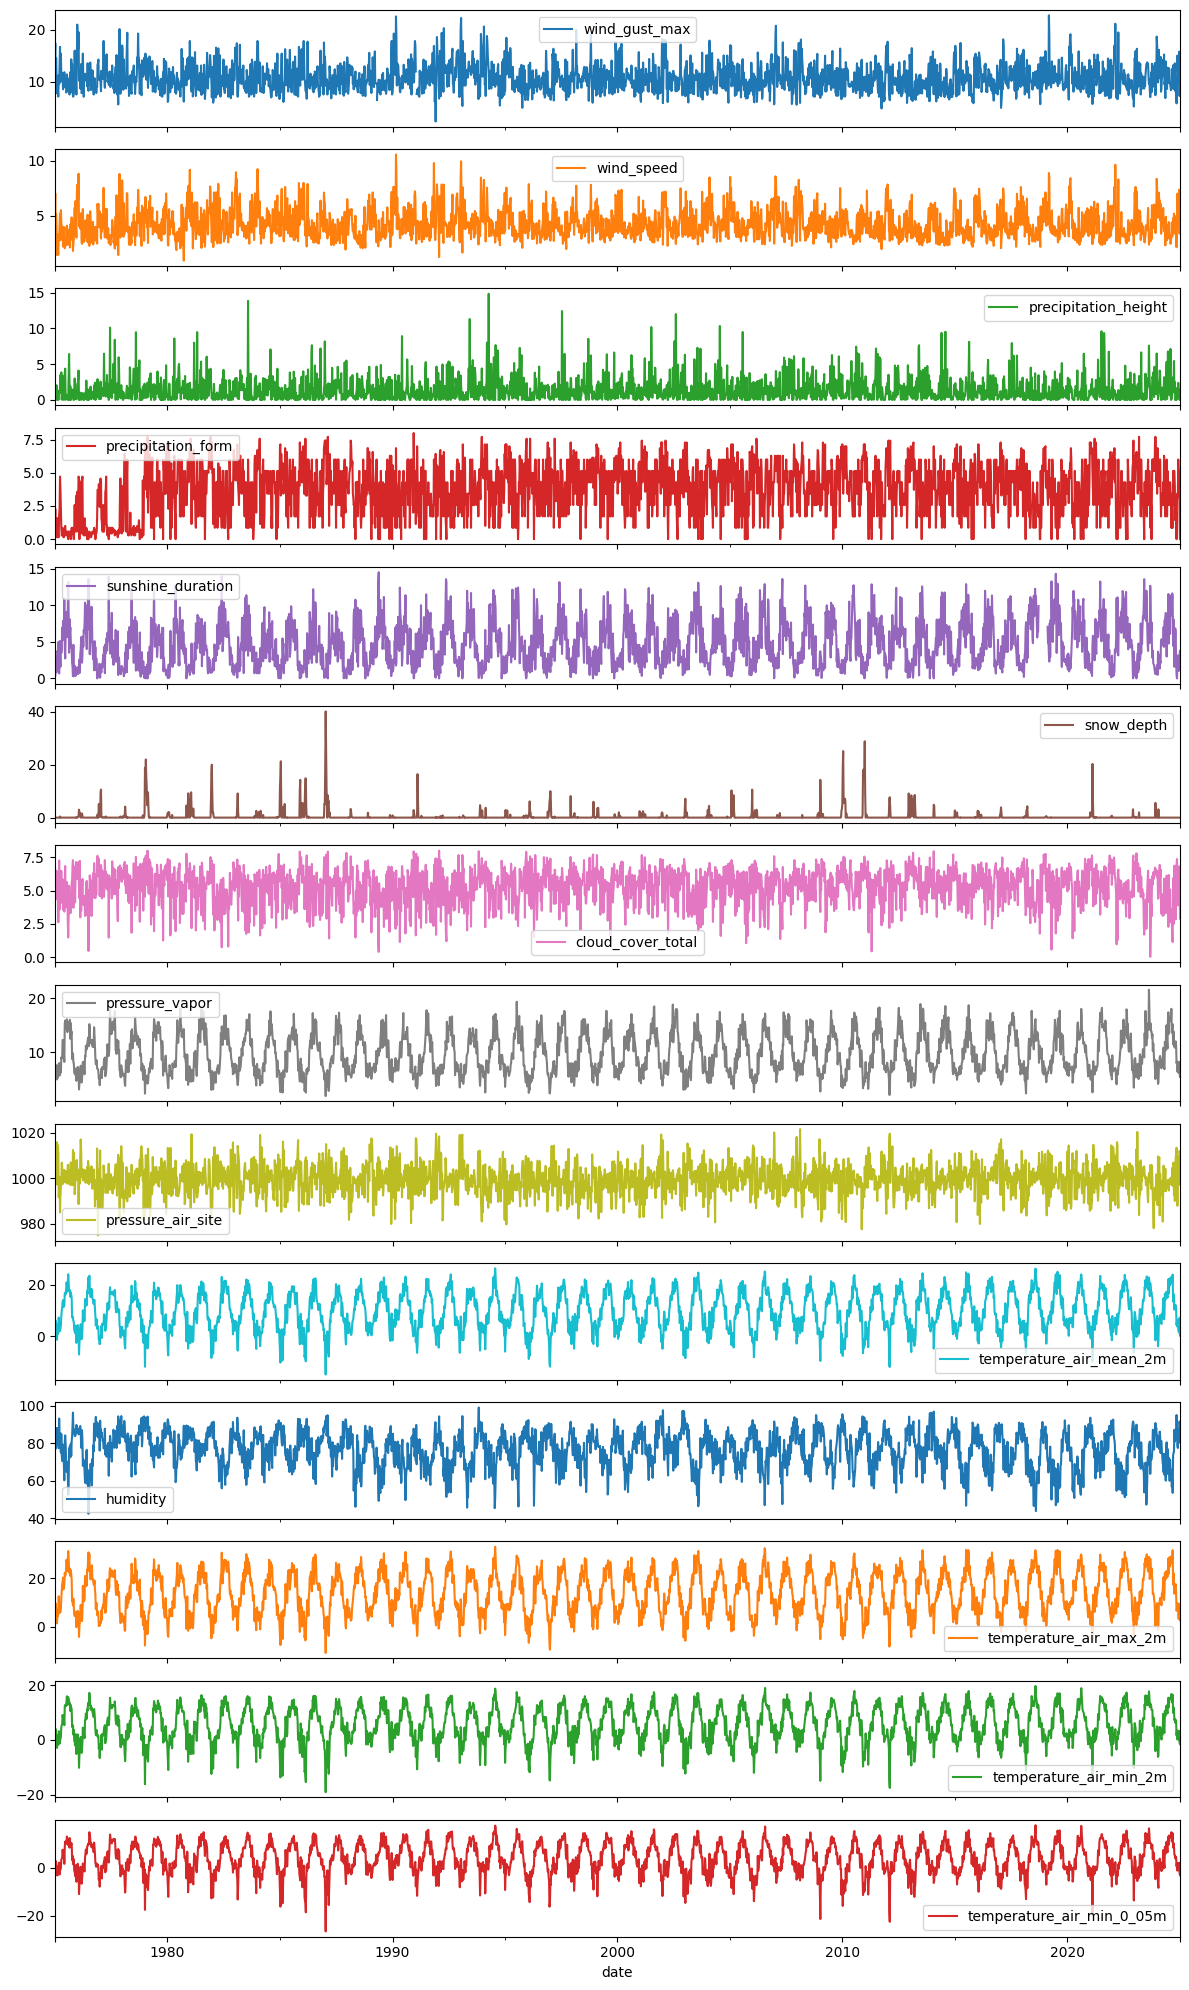

In [77]:
df_weekly.plot(subplots=True, figsize=(12, 20))
plt.tight_layout()
plt.show()

## Correlation Between Variables

Before modeling, it is useful to understand which variables are linearly related. High correlation can indicate:
- **Redundant features** (avoid multicollinearity in regression-based models)
- **Physically meaningful links** (e.g. temperature - vapour pressure)

> **Pitfall:**  
> Correlation in time series is often driven by a shared **trend or seasonality**, not a genuine relationship.  
> Two unrelated variables that both increase in summer will appear highly correlated.  
> Always verify with partial correlations or by checking the relationship on detrended/deseasonalised data.

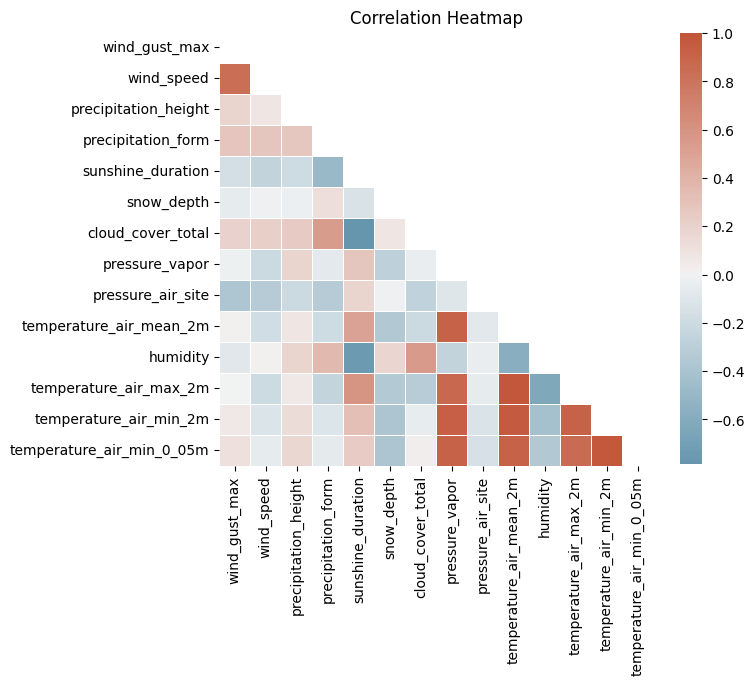

In [78]:
import numpy as np

corr = df_full.corr()#["temperature_air_mean_2m", "precipitation_height", "pressure_air_site", "pressure_vapor", "humidity"]].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(7, 8))
plt.title("Correlation Heatmap")

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.show()

## Decomposition

Time series decomposition separates a signal into interpretable components:

- **Trend**: Long-term increase or decrease
- **Seasonal**: Repeating pattern at a fixed period (e.g. yearly temperature cycle)
- **Residual**: What remains after removing trend and seasonality — ideally pure noise

Understanding these components is a prerequisite for choosing the right forecasting model.  
First, we handle missing values via linear interpolation before passing the data to decomposition methods (most of which cannot handle NaNs).

In [79]:
# limit_direction="both" fills interior NaNs in both directions.
# Since all NaNs here are interior gaps (not at series boundaries), this is safe.
df_full_interpolated = df_full.interpolate(method="linear", limit_direction="both")
df_weekly_interpolated = df_weekly.interpolate(method="linear", limit_direction="both")

In [80]:
df_full_interpolated.isna().sum()

wind_gust_max                0
wind_speed                   0
precipitation_height         0
precipitation_form           0
sunshine_duration            0
snow_depth                   0
cloud_cover_total            0
pressure_vapor               0
pressure_air_site            0
temperature_air_mean_2m      0
humidity                     0
temperature_air_max_2m       0
temperature_air_min_2m       0
temperature_air_min_0_05m    0
dtype: int64

In [81]:
df_weekly_interpolated.isna().sum()

wind_gust_max                0
wind_speed                   0
precipitation_height         0
precipitation_form           0
sunshine_duration            0
snow_depth                   0
cloud_cover_total            0
pressure_vapor               0
pressure_air_site            0
temperature_air_mean_2m      0
humidity                     0
temperature_air_max_2m       0
temperature_air_min_2m       0
temperature_air_min_0_05m    0
dtype: int64

### Classical Decomposition (`seasonal_decompose`)

Decomposes a time series into: **Trend + Seasonal + Residual**

Choose the model type:
- **Additive** (`model='additive'`): seasonal amplitude is roughly **constant** → suitable here for temperature
- **Multiplicative** (`model='multiplicative'`): seasonal amplitude **grows with the level** → common for economic or sales data

The trend is estimated with a **centered moving average** over one full season (here: 365 days).

> **Pitfall:**  
> The moving average loses `period/2` observations at both ends. With `period=365` you lose ~6 months of trend at the start and end of the series.  
> Also, classical decomposition assumes the seasonal pattern is **identical every year**, which may not hold over 50 years of climate data.

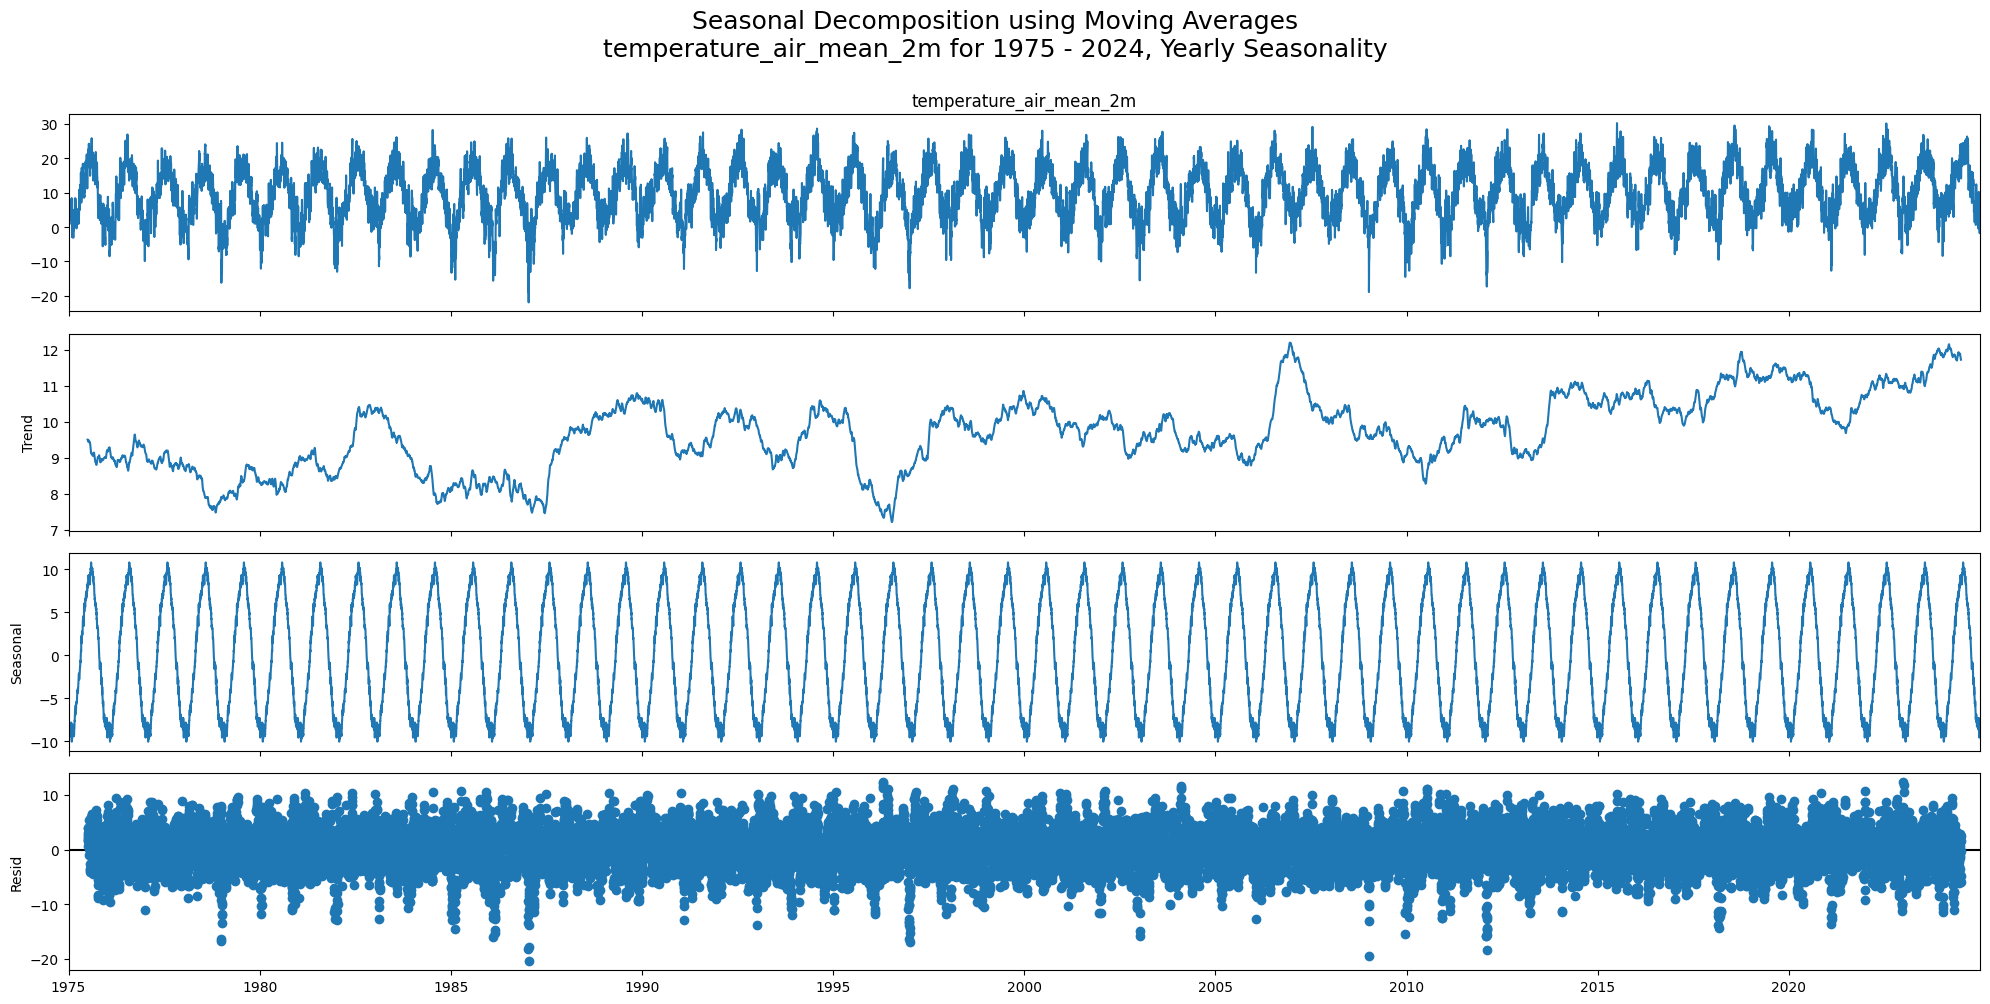

In [82]:
from statsmodels.tsa.seasonal import seasonal_decompose
selected_columns = ["temperature_air_mean_2m", "wind_speed", "precipitation_height", "humidity", "cloud_cover_total"]

# decompose for "temperature_air_mean_2m" only for clearer visualization, you may check other variables too

for col in ["temperature_air_mean_2m"]:
    seas_decomp_all = seasonal_decompose(df_full_interpolated[col], period=365)
    seas_decomp_all_fig = seas_decomp_all.plot()
    seas_decomp_all_fig.set_size_inches(20, 10)
    plt.suptitle(f"Seasonal Decomposition using Moving Averages\n{col} for 1975 - 2024, Yearly Seasonality", y=1.0, fontsize=18)
    plt.tight_layout()
    plt.show()

### STL Decomposition (Seasonal-Trend using LOESS)

STL is more flexible than classical decomposition:
- Uses **LOESS smoothing** instead of moving averages, which is more robust to outliers
- The **seasonal component can vary over time** (e.g. climate trends changing seasonal amplitude)
- Works only for **additive** models, but you can log-transform first for multiplicative behaviour

> **Pitfall:**  
> STL has more tuning parameters (`seasonal`, `trend`, `robust`).  
> The default `period` is the only required parameter, but the smoothing windows affect how much variation is attributed to trend vs. seasonal vs. residual.

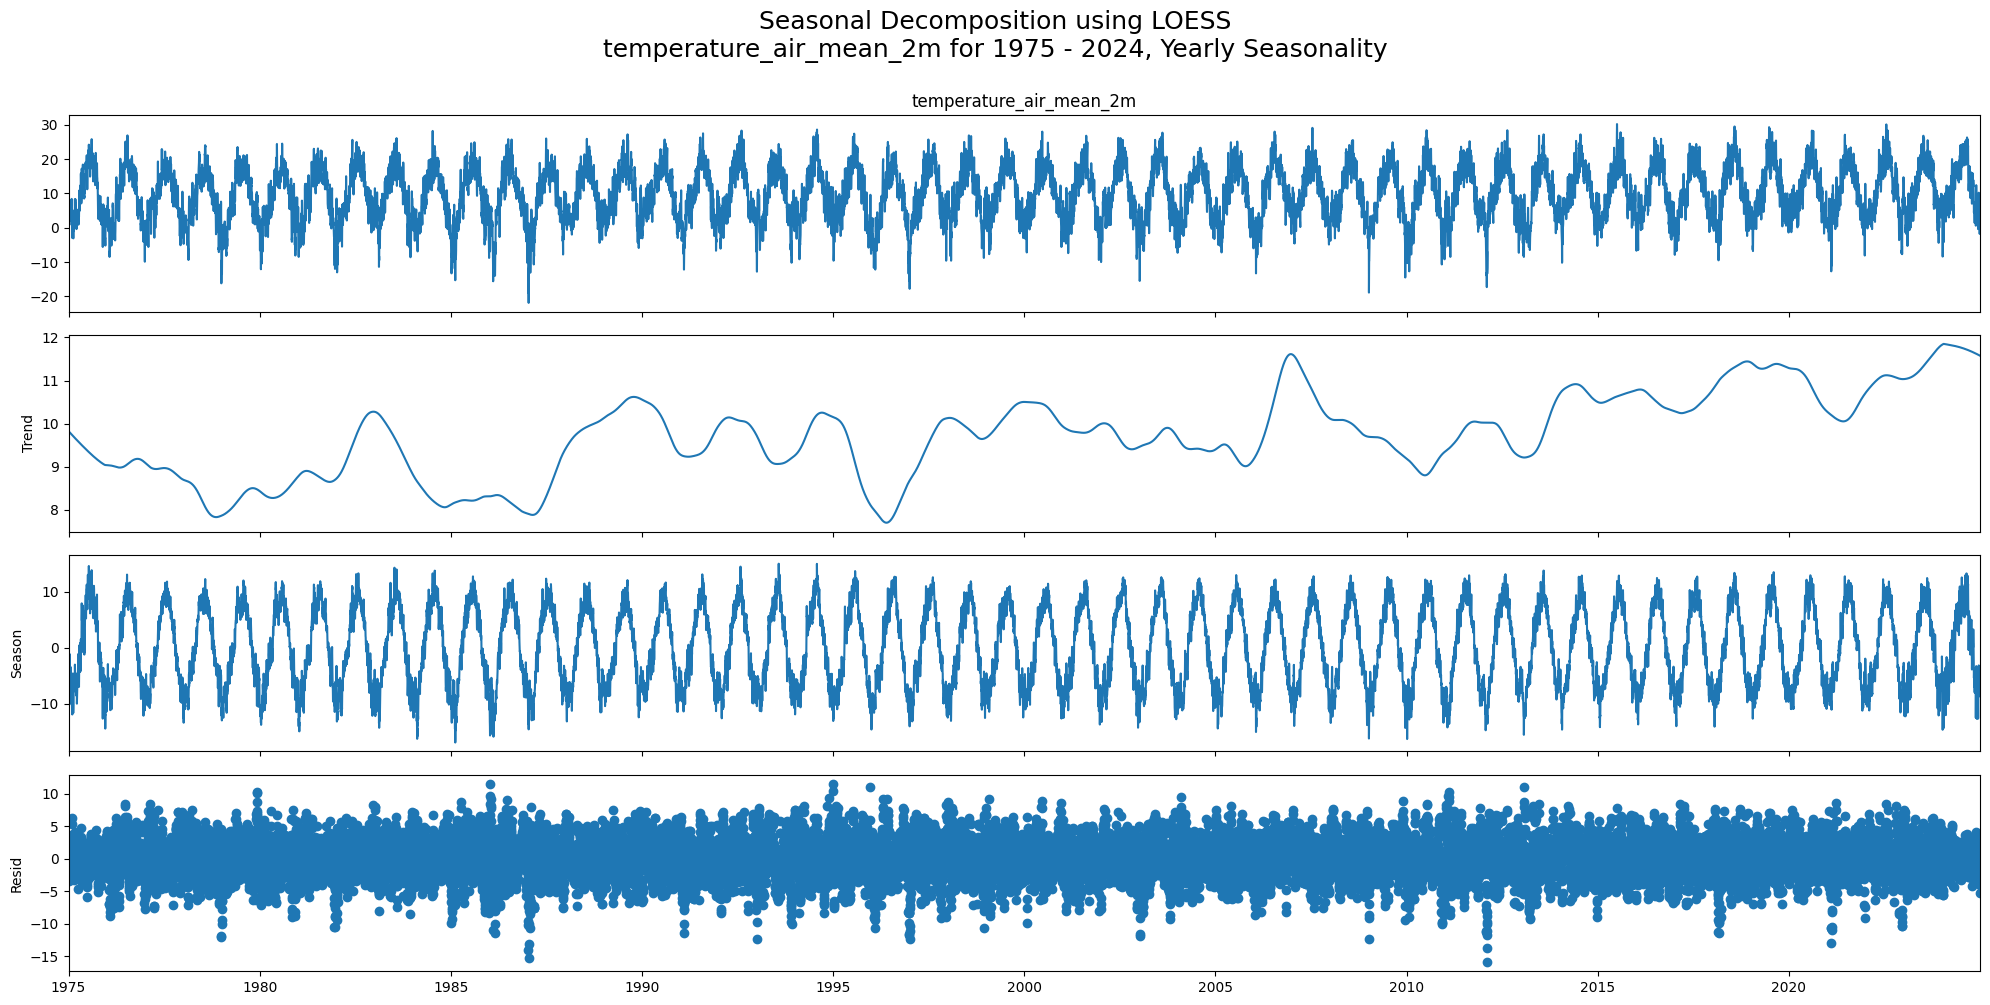

In [83]:
from statsmodels.tsa.seasonal import STL

# decompose for "temperature_air_mean_2m" only for clearer visualization, you may check other variables too

for col in ["temperature_air_mean_2m"]:
    stl_all_decomp_temp = STL(df_full_interpolated[col], period=365).fit()
    stl_decomp_all_fig = stl_all_decomp_temp.plot()
    stl_decomp_all_fig.set_size_inches(20, 10)
    plt.suptitle(f"Seasonal Decomposition using LOESS\n{col} for 1975 - 2024, Yearly Seasonality", y=1.0, fontsize=18)
    plt.tight_layout()
    plt.show()

### Seasonality Detection

`check_seasonality` runs a statistical test (based on autocorrelation significance) to determine whether a given lag is a dominant seasonal period.  
It scans all lags up to `max_lag` and returns the **first** significant one. We use `max_lag=365` to at least allow detection of the annual cycle.

> **Pitfall:**  
> `check_seasonality` returns the *first* statistically significant lag, not necessarily the dominant annual period.  
> On daily meteorological data, short weekly patterns (lag 7, 15) are often detected before the annual cycle (lag ~365).  
> A result like `period=7` does not mean there is no yearly seasonality. It means a 7-day pattern was found first.  
> Always cross-check with decomposition plots.

In [84]:
from darts.utils.statistics import check_seasonality

for col in df_full_interpolated.columns:
    seas_check = check_seasonality(TimeSeries.from_series(df_full_interpolated[col]), max_lag=365, alpha=0.05)
    print(f"Seasonality check for {col}: {seas_check}\n")

Seasonality check for wind_gust_max: (True, np.int64(20))

Seasonality check for wind_speed: (True, np.int64(15))

Seasonality check for precipitation_height: (True, np.int64(7))

Seasonality check for precipitation_form: (True, np.int64(8))

Seasonality check for sunshine_duration: (True, np.int64(10))

Seasonality check for snow_depth: (True, np.int64(326))

Seasonality check for cloud_cover_total: (True, np.int64(10))

Seasonality check for pressure_vapor: (True, np.int64(357))

Seasonality check for pressure_air_site: (True, np.int64(24))

Seasonality check for temperature_air_mean_2m: (True, np.int64(364))

Seasonality check for humidity: (True, np.int64(16))

Seasonality check for temperature_air_max_2m: (True, np.int64(361))

Seasonality check for temperature_air_min_2m: (True, np.int64(364))

Seasonality check for temperature_air_min_0_05m: (True, np.int64(356))



# Stationarity check

**Stationarity** means the statistical properties of the series (mean, variance, autocorrelation) do not change over time.  
Most classical forecasting models (ARIMA, exponential smoothing) assume stationarity or require the data to be made stationary first.

Two complementary tests are used because they test opposite null hypotheses:

| Test | H₀ | Reject H₀ when | Conclusion |
|------|----|-----------------|------------|
| **ADF** | Unit root exists (non-stationary) | p < 0.05 | Stationary |
| **KPSS** | Series is stationary | p < 0.05 | Non-stationary |

Using both together avoids false conclusions from either test alone.

_ADF and KPSS_  
* Case 1: Both tests conclude that the series is not stationary - The series is not stationary
* Case 2: Both tests conclude that the series is stationary - The series is stationary
* Case 3: KPSS indicates stationarity and ADF indicates non-stationarity - The series is trend stationary. Trend needs to be removed to make series strict stationary. The detrended series is checked for stationarity.
* Case 4: KPSS indicates non-stationarity and ADF indicates stationarity - The series is difference stationary. Differencing is to be used to make series stationary. The differenced series is checked for stationarity.


In [86]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(timeseries):
    dftest = adfuller(timeseries, autolag="AIC")
    print(f"\nResults of Dickey-Fuller Test for {timeseries.name}: ADF p-value: {dftest[1]}, Stationarity according to ADF: {dftest[1] < 0.05}")

def kpss_test(timeseries):
    
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    # Note: statsmodels caps KPSS p-values at 0.1 (upper) and 0.01 (lower), so 0.1 means p >= 0.1
    print(f"\nResults of KPSS Test for {timeseries.name}: KPSS p-value: {kpsstest[1]}, Stationarity according to KPSS: {kpsstest[1] > 0.05}")

In [87]:
for col in df_full_interpolated.columns:
    adf_test(df_full_interpolated[col])


Results of Dickey-Fuller Test for wind_gust_max: ADF p-value: 0.0, Stationarity according to ADF: True

Results of Dickey-Fuller Test for wind_speed: ADF p-value: 6.698667716383988e-25, Stationarity according to ADF: True

Results of Dickey-Fuller Test for precipitation_height: ADF p-value: 0.0, Stationarity according to ADF: True

Results of Dickey-Fuller Test for precipitation_form: ADF p-value: 1.8726189682511032e-23, Stationarity according to ADF: True

Results of Dickey-Fuller Test for sunshine_duration: ADF p-value: 8.929502995478205e-18, Stationarity according to ADF: True

Results of Dickey-Fuller Test for snow_depth: ADF p-value: 1.0549080131184806e-28, Stationarity according to ADF: True

Results of Dickey-Fuller Test for cloud_cover_total: ADF p-value: 3.962161486511157e-28, Stationarity according to ADF: True

Results of Dickey-Fuller Test for pressure_vapor: ADF p-value: 3.503880870456307e-16, Stationarity according to ADF: True

Results of Dickey-Fuller Test for pressure

In [88]:
for col in df_full_interpolated.columns:
    kpss_test(df_full_interpolated[col])


Results of KPSS Test for wind_gust_max: KPSS p-value: 0.07355594190638387, Stationarity according to KPSS: True

Results of KPSS Test for wind_speed: KPSS p-value: 0.1, Stationarity according to KPSS: True

Results of KPSS Test for precipitation_height: KPSS p-value: 0.1, Stationarity according to KPSS: True

Results of KPSS Test for precipitation_form: KPSS p-value: 0.01, Stationarity according to KPSS: False

Results of KPSS Test for sunshine_duration: KPSS p-value: 0.01, Stationarity according to KPSS: False

Results of KPSS Test for snow_depth: KPSS p-value: 0.1, Stationarity according to KPSS: True

Results of KPSS Test for cloud_cover_total: KPSS p-value: 0.09018326585657478, Stationarity according to KPSS: True

Results of KPSS Test for pressure_vapor: KPSS p-value: 0.1, Stationarity according to KPSS: True

Results of KPSS Test for pressure_air_site: KPSS p-value: 0.1, Stationarity according to KPSS: True

Results of KPSS Test for temperature_air_mean_2m: KPSS p-value: 0.1, St

### Convenience: `darts` Stationarity Test

`stationarity_tests()` wraps both ADF and KPSS into a single boolean result. It returns `True` only when both tests agree on stationarity (Case 2 in the table above). Useful for quick programmatic checks, but always inspect the individual p-values for borderline cases.

In [89]:
from darts.utils.statistics import stationarity_tests

for col in df_full_interpolated.columns:
    is_stationary = stationarity_tests(TimeSeries.from_series(df_full_interpolated[col]), p_value_threshold_adfuller=0.05, p_value_threshold_kpss=0.05)
    print(f"\nStationarity test for {col}: {is_stationary}")


Stationarity test for wind_gust_max: True

Stationarity test for wind_speed: True

Stationarity test for precipitation_height: True

Stationarity test for precipitation_form: False

Stationarity test for sunshine_duration: False

Stationarity test for snow_depth: True

Stationarity test for cloud_cover_total: True

Stationarity test for pressure_vapor: True

Stationarity test for pressure_air_site: True

Stationarity test for temperature_air_mean_2m: True

Stationarity test for humidity: False

Stationarity test for temperature_air_max_2m: True

Stationarity test for temperature_air_min_2m: True

Stationarity test for temperature_air_min_0_05m: True


# Autocorrelation

**ACF (Autocorrelation Function):** correlation between the series and its lagged copy at every lag k.  
**PACF (Partial ACF):** correlation at lag k *after removing* the effect of all shorter lags.

Use these to determine ARMA model orders:
- **ACF tails off, PACF cuts off at lag p**: AR(p)
- **ACF cuts off at lag q, PACF tails off**: MA(q)
- **Both tail off**: ARMA(p, q)
- **Slow sinusoidal decay in ACF**: strong seasonality present

> **Pitfall:**  
> With strong seasonality or trend, the ACF decays very slowly and the plot looks non-stationary even if the ADF test says otherwise.  
> Always decompose or difference before interpreting ACF for model order.

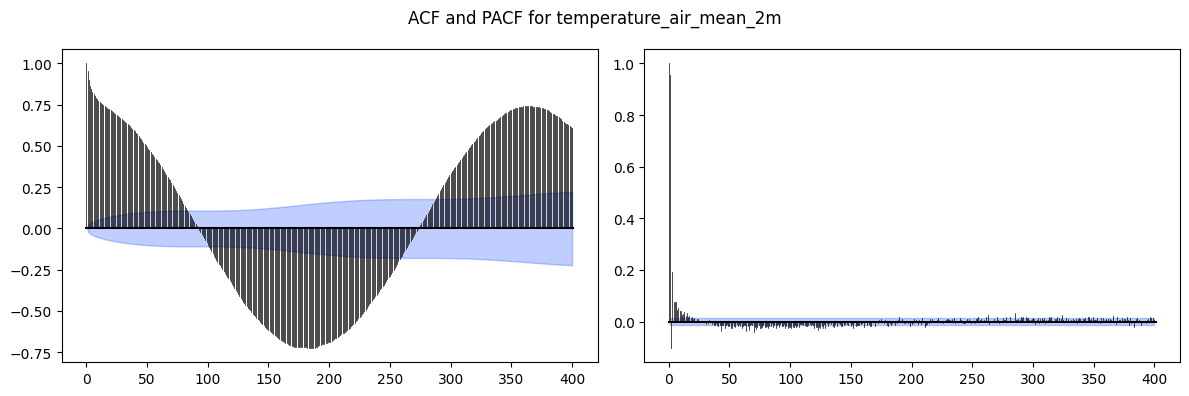

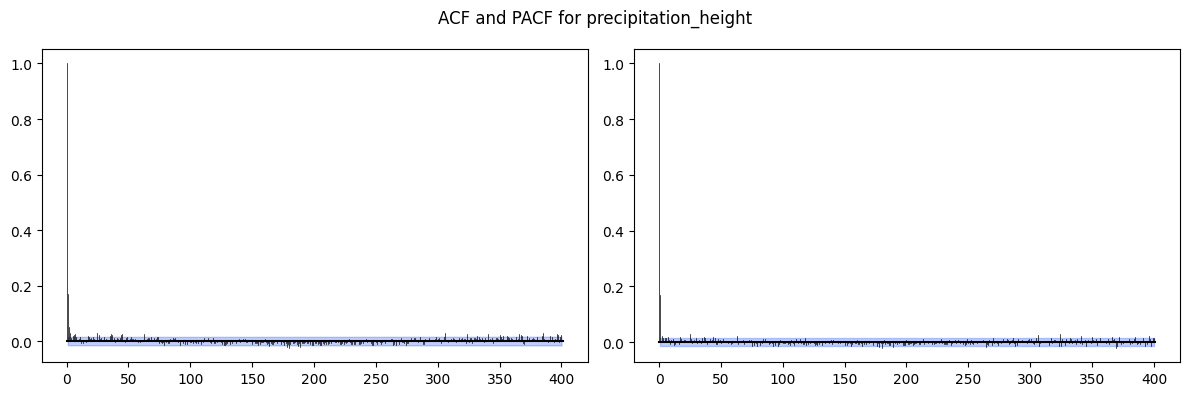

In [90]:
from darts.utils.statistics import plot_acf, plot_pacf

# Select two columns to plot ACF and PACF
for col in ["temperature_air_mean_2m", "precipitation_height"]:
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    plot_acf(TimeSeries.from_series(df_full_interpolated[col]), max_lag=400, alpha=0.05, axis=ax1)
    plot_pacf(TimeSeries.from_series(df_full_interpolated[col]), max_lag=400, alpha=0.05, axis=ax2)
    plt.suptitle(f'ACF and PACF for {col}')
    plt.tight_layout()
    plt.show()

### ACF / PACF on Weekly-Aggregated Data

Weekly resampling reduces noise and makes the annual seasonal structure more visible.  
The `m=52` parameter marks multiples of the seasonal period (52 weeks = 1 year) on the plot so you can visually distinguish seasonal autocorrelation from non-seasonal lags.

> **Pitfall:**  
> Without setting `m`, the seasonal spikes look like arbitrary autocorrelation and can be misread when estimating ARIMA/SARIMA orders.

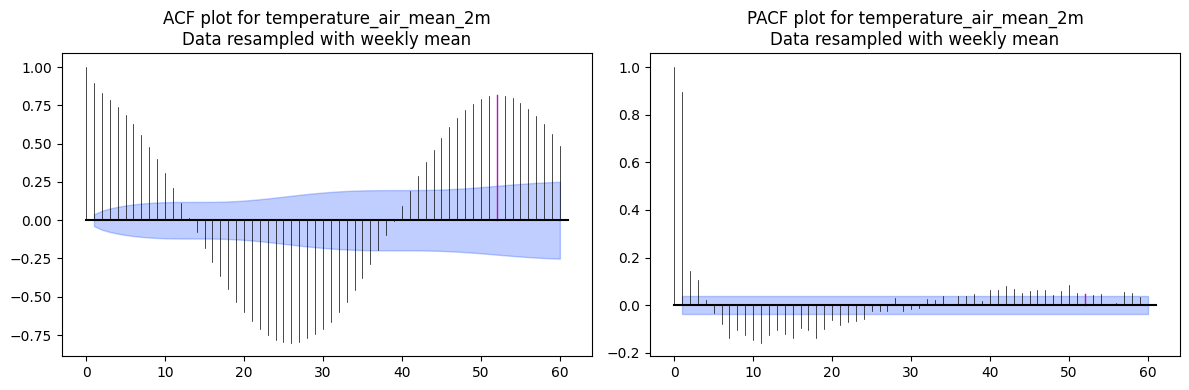

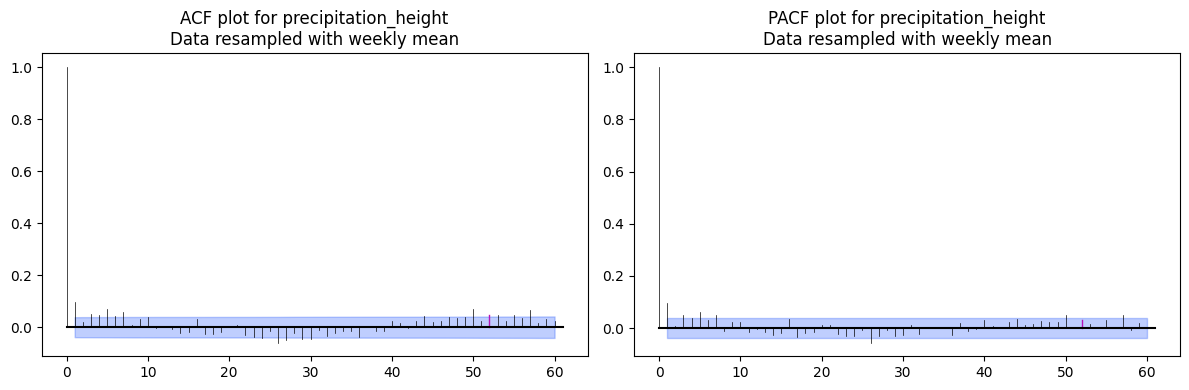

In [91]:
# Select two columns to plot ACF and PACF
for col in ["temperature_air_mean_2m", "precipitation_height"]:
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    plot_acf(TimeSeries.from_series(df_weekly_interpolated[col]), max_lag=60, m=52, alpha=0.05, axis=ax1)
    plot_pacf(TimeSeries.from_series(df_weekly_interpolated[col]), max_lag=60, m=52, alpha=0.05, axis=ax2)
    ax1.set_title(f'ACF plot for {col}\nData resampled with weekly mean')
    ax2.set_title(f'PACF plot for {col}\nData resampled with weekly mean')
    plt.tight_layout()
    plt.show()

## Distribution of Variables

Histograms reveal the marginal distribution of each variable. Relevant for:
- Spotting **skewness** or **heavy tails** that violate normality assumptions in many models
- Identifying **multimodal distributions** (e.g. precipitation: many zeros + positive tail)

Three variables are shown to contrast two typical cases:
- **Temperature**: roughly normal (bell-shaped), good candidate for linear models as-is
- **Wind speed**: moderately right-skewed
- **Precipitation**: heavily right-skewed (spike at zero + long tail), a log-transform or dedicated count model is usually needed

> **Pitfall:**  
> Many TS models (ARIMA, linear regression) assume Gaussian errors.  
> Strongly non-normal variables may benefit from a log-transform or Box-Cox transformation before modeling.

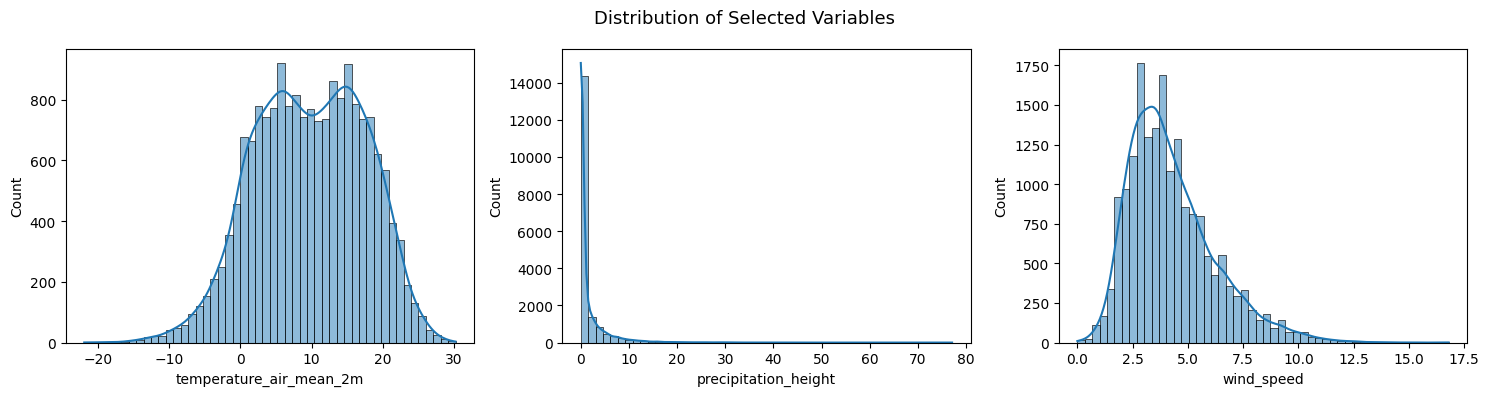

In [96]:
cols_to_plot = ["temperature_air_mean_2m", "precipitation_height", "wind_speed"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols_to_plot):
    sns.histplot(df_full_interpolated[col], bins=50, kde=True, ax=ax)
plt.suptitle("Distribution of Selected Variables", fontsize=13)
plt.tight_layout()
plt.show()

## Residuals Analysis

After decomposition, the **residuals** should be pure noise with no structure left. Check for:
- **Zero mean** and roughly **normal distribution** (model captured the signal)
- **No autocorrelation** in the residual ACF. If autocorrelation remains, the model missed patterns

> **Pitfall:**  
> Non-normal or autocorrelated residuals indicate the decomposition assumptions don't fully hold.  
> Consider a different period, model order, or transformation.

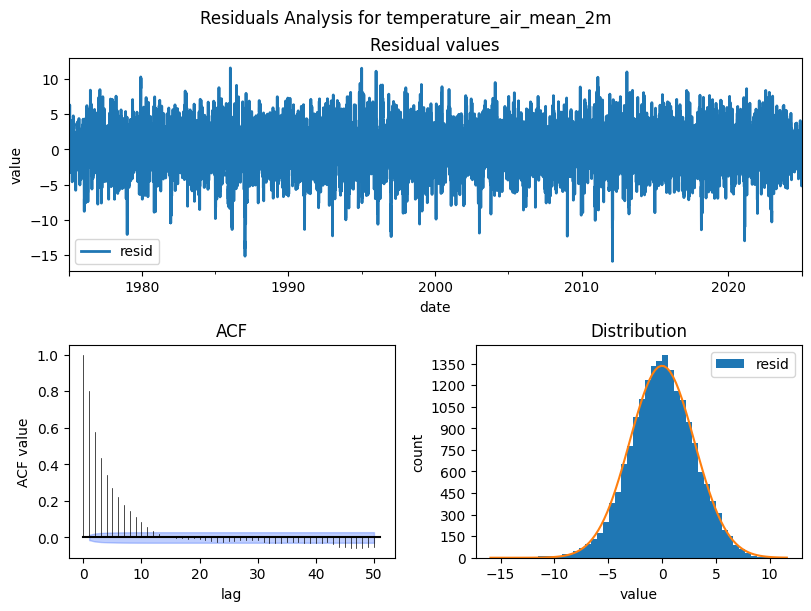

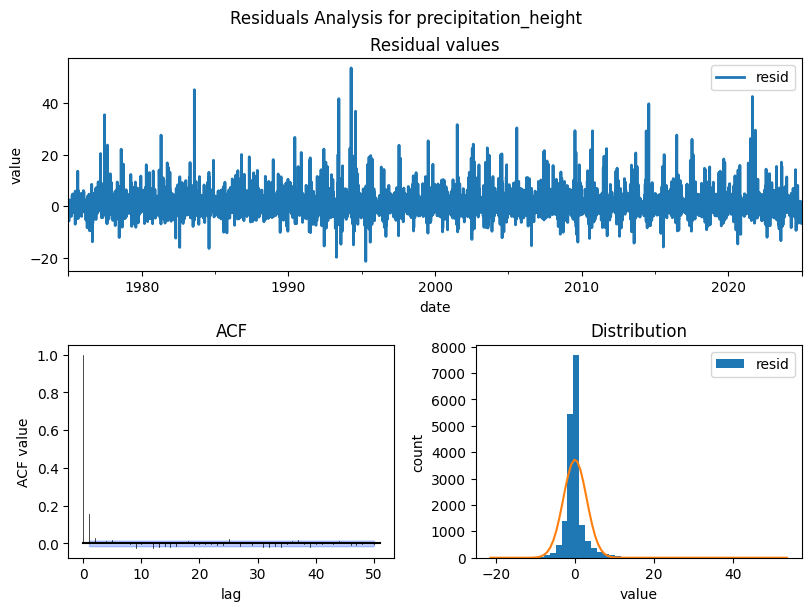

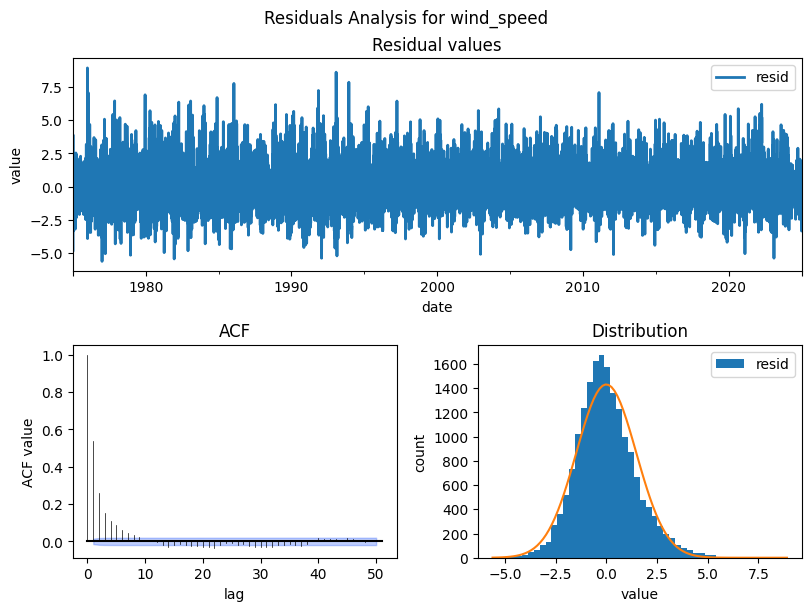

In [98]:
from darts.utils.statistics import plot_residuals_analysis

cols_to_plot = ["temperature_air_mean_2m", "precipitation_height", "wind_speed"]

for col in cols_to_plot:
    residuals = STL(df_full_interpolated[col], period=365).fit().resid
    plot_residuals_analysis(TimeSeries.from_series(residuals), num_bins=50, fill_nan=True, default_formatting=True, acf_max_lag=50)
    plt.suptitle(f'Residuals Analysis for {col}')
    plt.show()